Outlier removal using z score

              Outlier treatment
    
    1--> Trimming
    2--> Capping

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
962,7.09,46.0,1
251,6.46,45.0,0
35,7.48,12.0,0
84,5.65,35.0,1
506,7.84,8.0,1


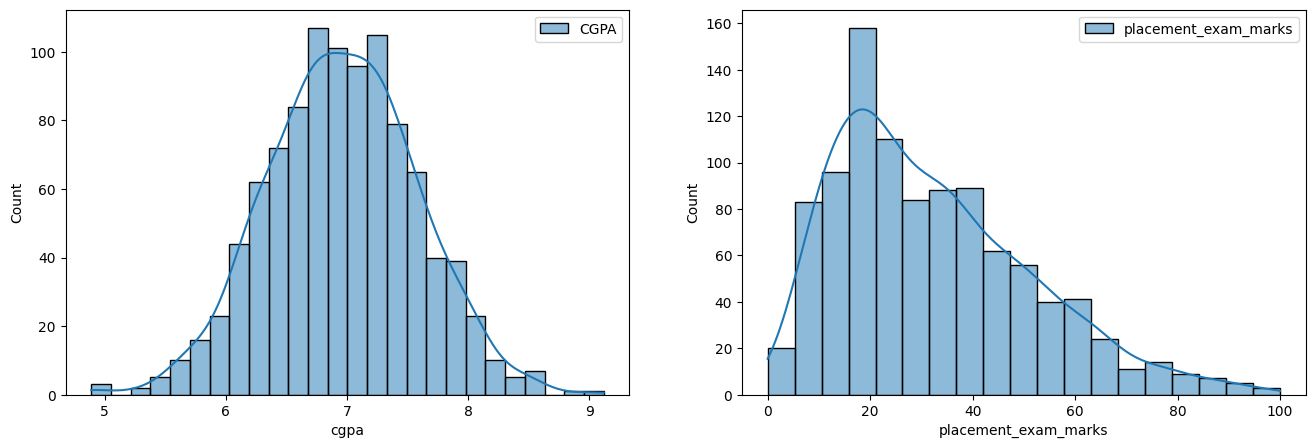

In [18]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(df['cgpa'],label='CGPA',kde=True)
plt.legend()
plt.subplot(122)
sns.histplot(df['placement_exam_marks'],kde=True,label='placement_exam_marks')
plt.legend()

In [21]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [23]:
print("Highest allowed :",df['cgpa'].mean()+3*df['cgpa'].std())
print("Lowest allowed :",df['cgpa'].mean()-3*df['cgpa'].std())

Highest allowed : 8.808933625397168
Lowest allowed : 5.113546374602832


In [24]:
#finding outliers
df[(df['cgpa']>8.80) | (df['cgpa']<5.11) ]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


Trimming

In [30]:
#trimming
new_df=df[(df['cgpa']<8.80) & (df['cgpa']>5.11) ]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [31]:
df.shape,new_df.shape

((1000, 3), (995, 3))

In [34]:
#approach 2 for z_score
df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [35]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [37]:
df[(df['cgpa_zscore']>3 )| (df['cgpa_zscore']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [41]:
new_df=df[(df['cgpa_zscore']<3 )& (df['cgpa_zscore']>-3)]
new_df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [42]:
df.shape,new_df.shape

((1000, 4), (995, 4))

                        Capping

In [45]:
upper_limit=df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit=df['cgpa'].mean() - 3*df['cgpa'].std()

In [ ]:
upper_limit,lower_limit

(8.808933625397168, 5.113546374602832)

In [47]:
df['cgpa']=np.where(df['cgpa']>upper_limit,upper_limit,
                    np.where(df['cgpa']<lower_limit,
                             lower_limit,
                             df['cgpa']))

In [48]:
df.shape

(1000, 4)

In [49]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64